# Market Positioning — Model-Based Quantile Analysis

While the previous notebook used actual competitor prices to assess positioning,
in production we don't have those prices — that's exactly what the model is for.

This notebook shows how the trained model is used to **score** each quote:

1. For a given quote, run the model to predict the full distribution of what
   competitors would charge (19 quantiles, one per quantile level)
2. Compare our own price against this predicted distribution to get a
   **scoring** — the fraction of the market we are cheaper than
3. Analyse how scoring varies across feature segments

A scoring of 0.8 means our price is below 80% of predicted competitor prices —
we are very competitive on that quote. A scoring of 0.2 means we are expensive
relative to the predicted market.

In [1]:
import sys
sys.path.insert(0, '../')

import joblib
import pandas as pd
import numpy as np
from plotnine import *

pd.set_option('display.max_columns', 100)

## 1. Load Data and Model

In [2]:
df = pd.read_csv('../data/results_data.csv')
model = joblib.load('../models/model.pkl')

print(f"Quotes: {len(df):,}")
df[['own_price', 'scoring']].describe().round(3)

Quotes: 1,000


,own_price,scoring
count,1000.000,1000.000
mean,10403.053,0.509
std,3494.233,0.220
min,3443.260,0.000
25%,7929.035,0.400
50%,9710.410,0.600
75%,12436.760,0.600
max,24995.930,1.000


## 2. Compute Model-Predicted Scoring

For each quote we create one row per competitor (5 rows total), run the model
to get the predicted price distribution for that (quote, competitor) pair, then
average across competitors to get the overall market distribution for that quote.

The scoring is then: `fraction of predicted quantiles below own_price`.

In [3]:
COMPETITORS = [f'comp_{i}' for i in range(1, 6)]
alphas = np.arange(0.05, 1.0, 0.05)

feature_cols = (
    [f'num_feature_{i}' for i in range(1, 13)]
    + [f'geo_feature_{i}' for i in range(1, 10)]
    + [f'cat_feature_{i}' for i in range(1, 10)]
)

def predict_market_distribution(model, df_wide, competitors):
    """
    For each quote, predict the market price distribution by running the model
    once per competitor and averaging the predicted quantiles.

    Returns an array of shape (n_quotes, n_quantiles).
    """
    all_preds = []
    for comp in competitors:
        chunk = df_wide[feature_cols].copy()
        chunk['competitor_id'] = comp
        all_preds.append(model.predict(chunk))   # (n_quotes, 19)

    # Stack: (n_competitors, n_quotes, 19) → average over competitors
    return np.stack(all_preds, axis=0).mean(axis=0)


market_dist = predict_market_distribution(model, df, COMPETITORS)
print(f"Market distribution shape: {market_dist.shape}")

# Model-predicted scoring: fraction of quantiles below own_price
df['model_scoring'] = (df['own_price'].values[:, None] < market_dist).mean(axis=1).round(3)

print("\nModel scoring vs actual scoring (from real competitor prices):")
print(df[['scoring', 'model_scoring']].describe().round(3))

Market distribution shape: (1000, 19)

Model scoring vs actual scoring (from real competitor prices):
        scoring  model_scoring
count  1000.000       1000.000
mean      0.509          0.530
std       0.220          0.230
min       0.000          0.000
25%       0.400          0.368
50%       0.600          0.526
75%       0.600          0.737
max       1.000          1.000


## 3. Scoring Distribution

Overall distribution of model-predicted scoring across all quotes.

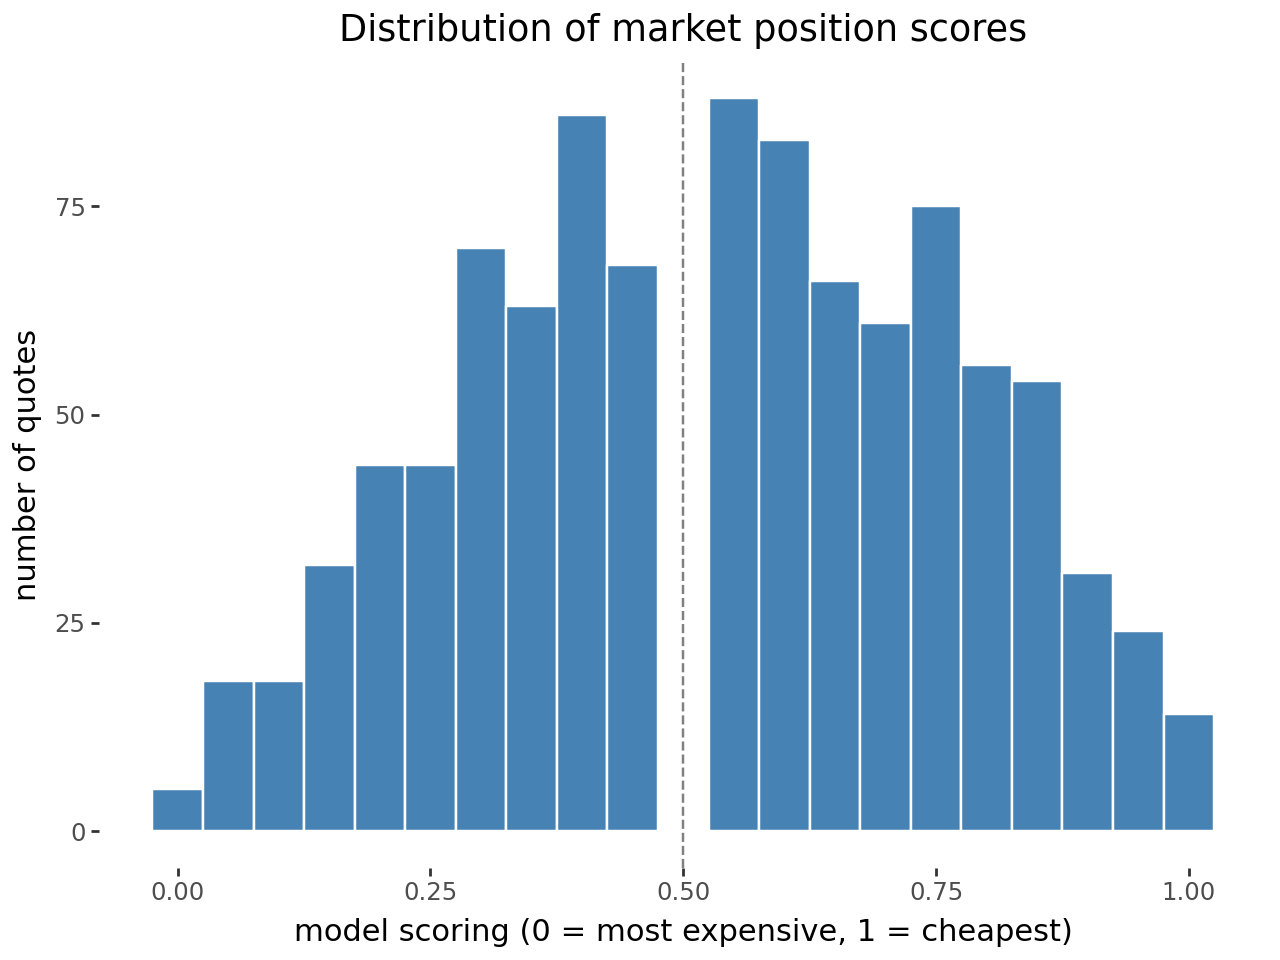

In [4]:
(ggplot(df, aes(x='model_scoring'))
 + geom_histogram(binwidth=0.05, fill='steelblue', color='white')
 + geom_vline(xintercept=0.5, linetype='dashed', color='gray')
 + theme(panel_background=element_rect(fill='white'), panel_grid_minor=element_blank())
 + labs(x='model scoring (0 = most expensive, 1 = cheapest)',
        y='number of quotes',
        title='Distribution of market position scores')
)

## 4. Scoring by Feature Segment

Break down market position by key features to identify where our pricing
is systematically above or below the predicted market.

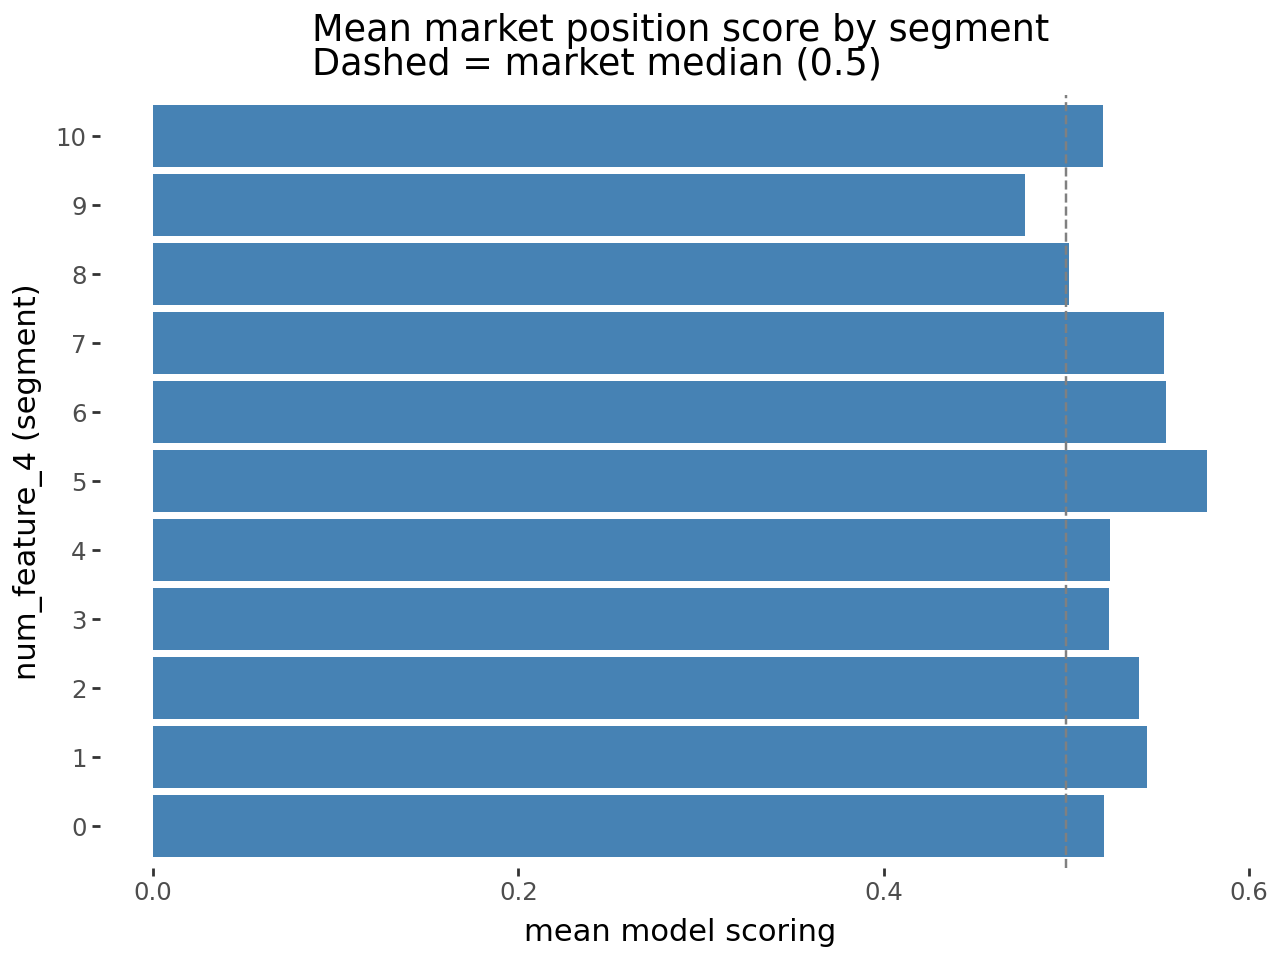

In [5]:
# By ordinal feature (0-10 range)
seg_num = (
    df.groupby('num_feature_4')['model_scoring']
    .mean()
    .reset_index()
)

(ggplot(seg_num, aes(x='factor(num_feature_4)', y='model_scoring'))
 + geom_col(fill='steelblue')
 + geom_hline(yintercept=0.5, linetype='dashed', color='gray')
 + coord_flip()
 + theme(panel_background=element_rect(fill='white'), panel_grid_minor=element_blank())
 + labs(x='num_feature_4 (segment)', y='mean model scoring',
        title='Mean market position score by segment\nDashed = market median (0.5)')
)

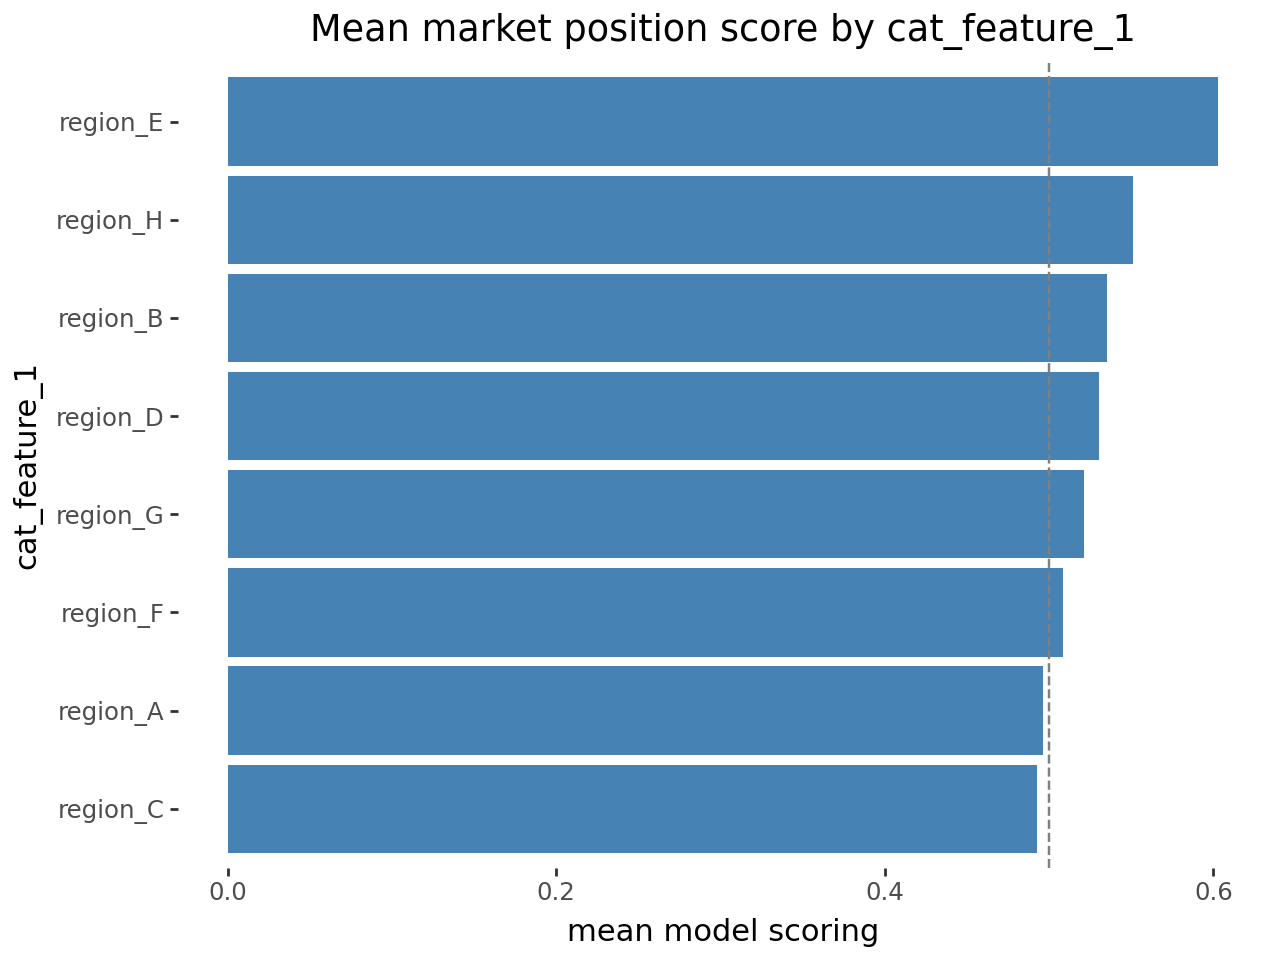

In [6]:
# By categorical feature
seg_cat = (
    df.groupby('cat_feature_1')['model_scoring']
    .mean()
    .reset_index()
    .sort_values('model_scoring')
)

(ggplot(seg_cat, aes(x='reorder(cat_feature_1, model_scoring)', y='model_scoring'))
 + geom_col(fill='steelblue')
 + geom_hline(yintercept=0.5, linetype='dashed', color='gray')
 + coord_flip()
 + theme(panel_background=element_rect(fill='white'), panel_grid_minor=element_blank())
 + labs(x='cat_feature_1', y='mean model scoring',
        title='Mean market position score by cat_feature_1')
)

## 5. Model Score vs Actual Score

How well does the model-predicted scoring match the actual scoring computed
from real competitor prices? A well-calibrated model should produce a tight
correlation along the diagonal.

Pearson correlation (actual vs model scoring): 0.663


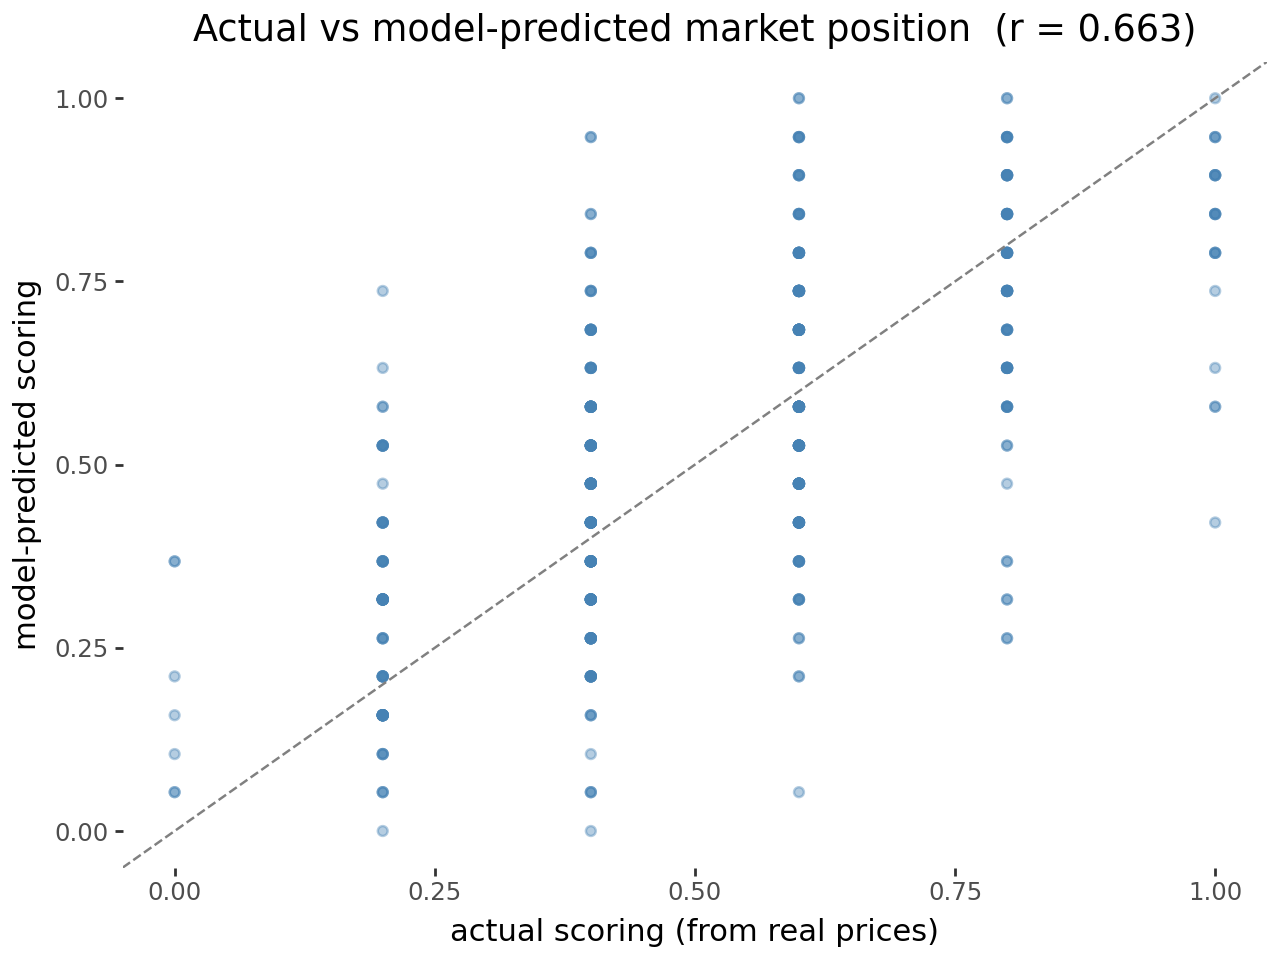

In [7]:
corr = df[['scoring', 'model_scoring']].corr().loc['scoring', 'model_scoring']
print(f"Pearson correlation (actual vs model scoring): {corr:.3f}")

(ggplot(df.sample(500, random_state=42), aes(x='scoring', y='model_scoring'))
 + geom_point(alpha=0.4, color='steelblue')
 + geom_abline(slope=1, intercept=0, linetype='dashed', color='gray')
 + theme(panel_background=element_rect(fill='white'), panel_grid_minor=element_blank())
 + labs(x='actual scoring (from real prices)', y='model-predicted scoring',
        title=f'Actual vs model-predicted market position  (r = {corr:.3f})')
)